# Pulse analysis setup
Imports and environment setup for pulse extraction and epoching.

In [21]:
%matplotlib inline
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import mne

C:\Users\njeuk\AppData\Local\Temp\ipykernel_37688\4058794396.py:5: RuntimeWarning: No coordinate information found for channels ['ground_truth', 'stim']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
C:\Users\njeuk\AppData\Local\Temp\ipykernel_37688\4058794396.py:5: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
C:\Users\njeuk\AppData\Local\Temp\ipykernel_37688\4058794396.py:5: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (500.00 Hz, Nyquist limit) will be stored.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)


Loaded: C:\Users\njeuk\OneDrive\Documents\Charite Berlin\TIMS\TIMS_data_sync\pilot\doseresp\exp02-phantom-stim-pulse-10hz-GT-run01.vhdr  sfreq=1000 Hz
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


C:\Users\njeuk\AppData\Local\Temp\ipykernel_37688\4058794396.py:5: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['ground_truth', 'stim']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)


Channels after drop: ['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
Dropped BAD_CHANNELS: ['T7', 'TP9', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'T8', 'FT10', 'F7', 'CP5', 'CP6', 'CP2', 'FC5', 'FT9', 'C3']
Channels after bad channel drop: ['Fp1', 'F3', 'FC1', 'CP1', 'Cz', 'C4', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']


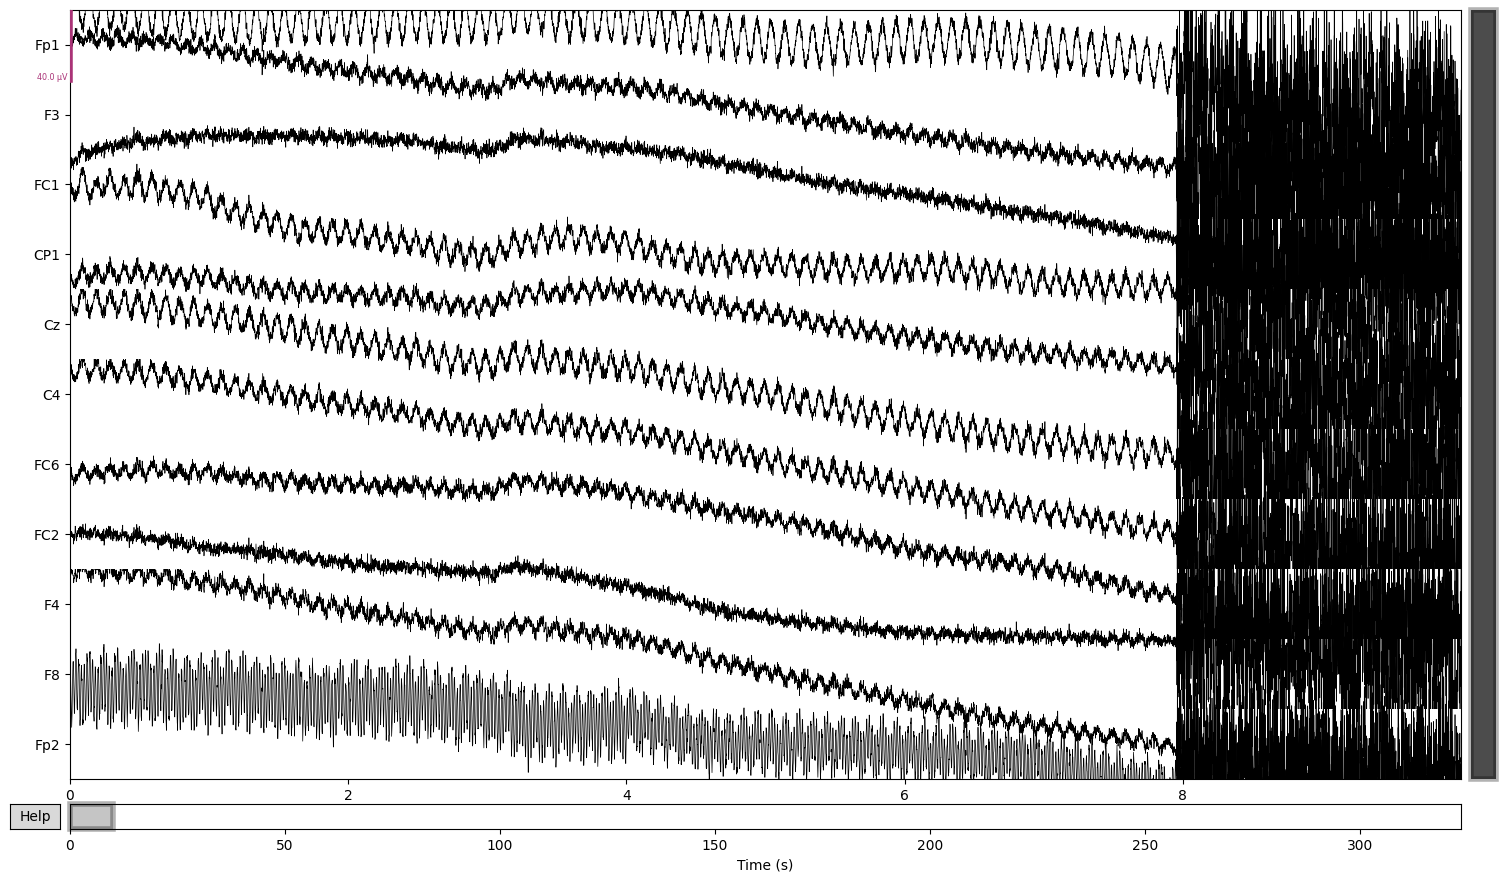

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


C:\Users\njeuk\AppData\Roaming\Python\Python310\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


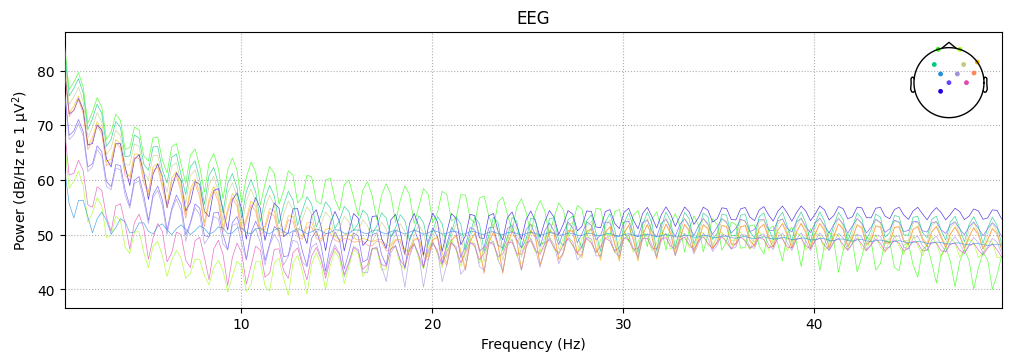

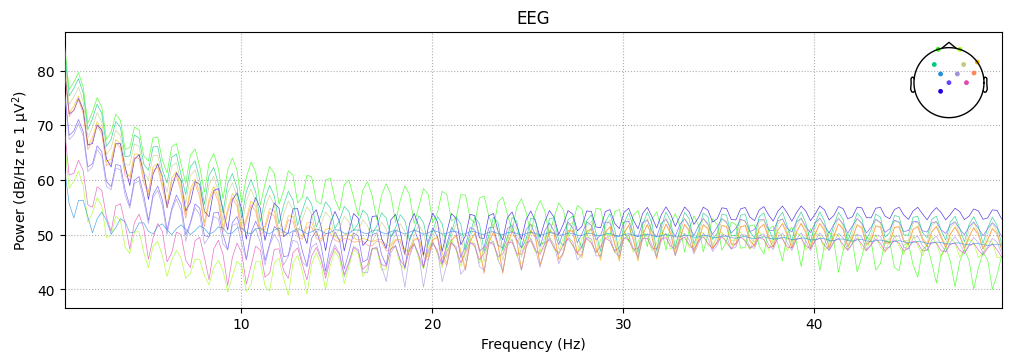

In [99]:
from pathlib import Path
from preprocess_min import detect_and_remove_bad_channels

vhdr_path = r"C:\Users\njeuk\OneDrive\Documents\Charite Berlin\TIMS\TIMS_data_sync\pilot\doseresp\exp02-phantom-stim-pulse-10hz-GT-run01.vhdr"
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
print(f"Loaded: {vhdr_path}  sfreq={raw.info['sfreq']:.0f} Hz")
# keep only EEG channels (drop stim / ground_truth / STI* etc.)
raw_eeg = raw.copy().pick_types(eeg=True, stim=False, misc=False)  # just for info
eeg_chs = raw_eeg.ch_names
non_eeg = [ch for ch in raw_eeg.ch_names if ch not in eeg_chs]
if non_eeg:
    raw_eeg.drop_channels(non_eeg)
print("Channels after drop:", raw_eeg.ch_names)

# basic filtering (consistent with repo preprocessing)
#raw.notch_filter([50.0], notch_widths=2, verbose=False)
#raw.filter(0.1, 50.0, verbose=False)
BAD_CHANNELS = ['T7', 'TP9', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 
                'TP10', 'T8', 'FT10', 'F7', 'CP5', 'CP6', 'CP2', 'FC5', 'FT9', 'C3']  # bad channels to drop (if present)
to_drop = [ch for ch in BAD_CHANNELS if ch in raw.ch_names]
if to_drop:
    raw_eeg.drop_channels(to_drop)
    print('Dropped BAD_CHANNELS:', to_drop)
# detect + drop bad channels (variance + flat)
#bads = detect_and_remove_bad_channels(raw, std_factor=5.0, flat_thresh=1e-12, max_bad_frac=0.30, drop=True, verbose=True)
#print("Auto-detected bads:", bads)
print("Channels after bad channel drop:", raw_eeg.ch_names)
# interactive checks
raw_eeg.plot(n_channels=min(32, len(raw_eeg.ch_names)), block=False)
raw_eeg.compute_psd(fmin=0.5, fmax=50.0, method="welch", n_fft=4096, n_per_seg=4096, n_overlap=2048).plot()

In [86]:
import numpy as np
from plot_helpers import detect_pulses

sfreq = raw.info['sfreq']
cands = [c for c in raw.ch_names if any(k in c.lower() for k in ('stim','sti','ground_truth'))]
if not cands:
    raise RuntimeError("No stim/ground_truth channel found in raw")
print("Candidate stim channels:", cands)

stim_ch = cands[1]
# 2) compute analytic envelope of stim waveform (Hilbert) as detection metric
s = raw.copy().pick([stim_ch]).get_data()[0]
envelope = np.abs(signal.hilbert(s))
print(f"Stim channel '{stim_ch}'  raw min={s.min():.3f} max={s.max():.3f}  \nenvelope min={envelope.min():.3f} max={envelope.max():.3f}")


peaks, s = detect_pulses(raw, ch="stim", distance_ms=3000, prominence=None)
print(f"Detected {len(peaks)} pulse events every {1000*(peaks[1]-peaks[0])/sfreq:.1f}s")
print("Peak times (s):", peaks / sfreq)

# let's plot the seconds: 10-15s of the raw and envelope to see if the pulse events are visible
# t = np.arange(len(s)) / sfreq
# plt.figure(figsize=(12, 6))
# plt.plot(t, s, label='Stim raw')
# plt.plot(t, envelope, label='Stim envelope')    
# plt.xlim(10, 15)
# plt.ylim(0, 1.1 * s.max())
# plt.xlabel('Time (s)')
# plt.legend()

Candidate stim channels: ['ground_truth', 'stim']
Stim channel 'stim'  raw min=0.053 max=0.986  
envelope min=0.053 max=0.986
Detected 75 pulse events every 4000.0s: [ 11.982  15.982  19.981  23.981  27.982  31.982  35.982  39.982  43.982
  47.982  51.981  55.981  59.981  63.981  67.981  71.981  75.981  79.981
  83.981  87.981  91.981  95.981  99.981 103.981 107.981 111.981 115.981
 119.981 123.981 127.981 131.981 135.981 139.981 143.981 147.981 151.981
 155.981 159.981 163.981 167.981 171.981 175.981 179.981 183.981 187.981
 191.981 195.981 199.981 203.981 207.981 211.981 215.981 219.981 223.981
 227.981 231.981 235.981 239.981 243.981 247.981 251.981 255.981 259.981
 263.981 267.981 271.981 275.981 279.981 283.981 287.981 291.981 295.981
 299.981 303.981 307.981] sec


Using 75 peaks for epoching after edge exclusion (pre=1.0s post=3.0s).
Created 75 STIM epochs and 75 NO-STIM epochs (pre=1.0s post=3.0s).
STIM epoch shape: (75, 33, 1001)
NO-STIM epoch shape: (75, 33, 3001)
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\njeuk\AppData\Roaming\Python\Python310\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


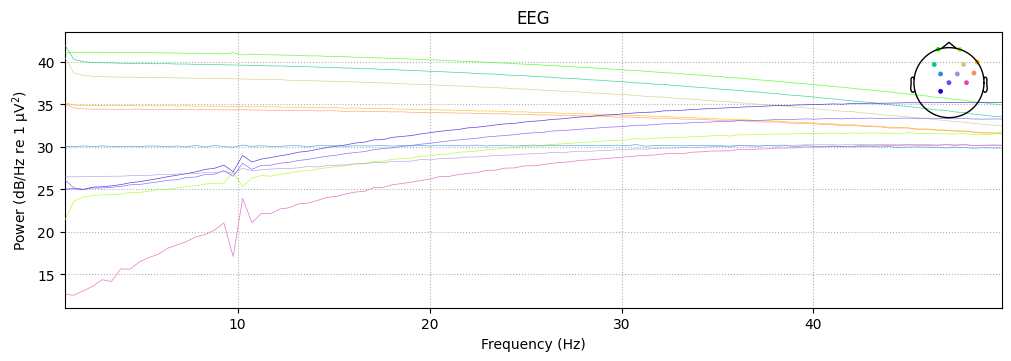

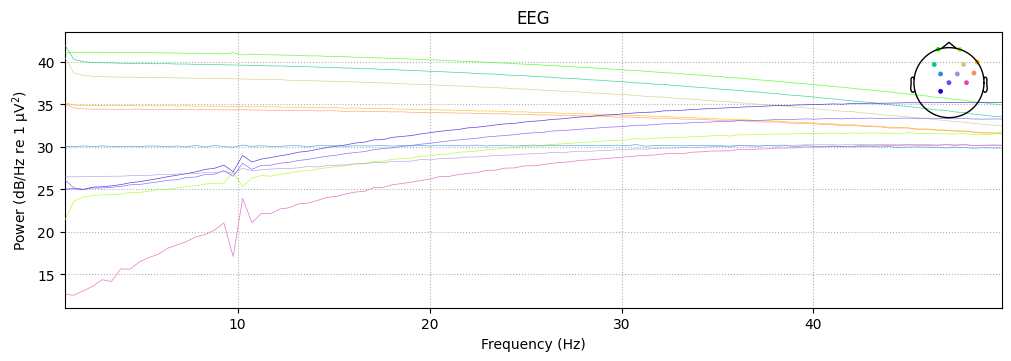

In [106]:
# Creating EPOCH around detected pulse events

# define epoch windows
pre_sec = 1.0; post_sec = 3.0
min_idx = int(pre_sec * sfreq); max_idx = len(s) - int(post_sec * sfreq) - 1

# Keep peak that are 3s before and 1s after
valid = peaks[(peaks >= min_idx) & (peaks <= max_idx)]
if valid.size == 0:
    print("No usable peaks for epoching (edge exclusion).")
else:
    print(f"Using {len(valid)} peaks for epoching after edge exclusion (pre={pre_sec}s post={post_sec}s).")

    # build events: one event id=1 (STIM) and one id=2 (NO_STIM) per peak (same sample)
    stim_events = np.column_stack([valid, np.zeros(len(valid), int), np.ones(len(valid), int)])
    no_events   = np.column_stack([valid, np.zeros(len(valid), int), np.full(len(valid), 2, int)])
    events      = np.vstack([stim_events, no_events])

    # create epochs for each condition with appropriate windows
    stim_epochs = mne.Epochs(raw, stim_events, event_id=1, tmin=-pre_sec, tmax=0.0, preload=True, verbose=False)
    no_epochs   = mne.Epochs(raw, no_events,   event_id=2, tmin=0.0,  tmax=post_sec, baseline=None, preload=True, verbose=False)
    print(f"Created {len(stim_epochs)} STIM epochs and {len(no_epochs)} NO-STIM epochs (pre={pre_sec}s post={post_sec}s).")

print("STIM epoch shape:", stim_epochs.get_data().shape)  # (n_epochs, n_channels, n_times)
print("NO-STIM epoch shape:", no_epochs.get_data().shape)
chans = ['Fp1', 'F3', 'FC1', 'CP1', 'Cz', 'C4', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
no_epochs.compute_psd(fmin=0.5, fmax=50.0, method="welch").plot(picks=chans)

NameError: name 'freqs' is not defined

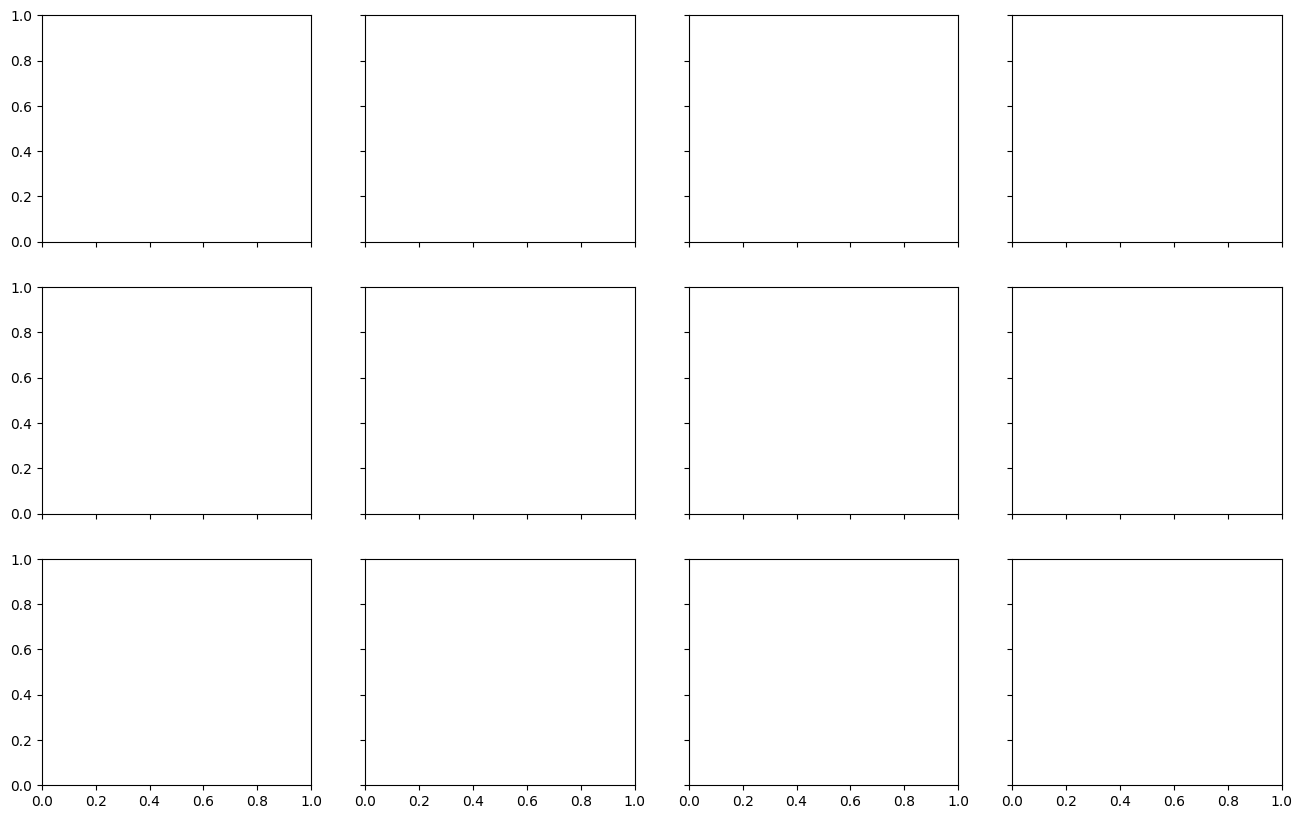

In [116]:
# Plot STIM vs NO-STIM PSD curves per channel
# ps_s / ps_n shape: (n_epochs, n_channels, n_freqs)
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()
for i, ch in enumerate(chans):
    ax = axes[i]
    ms = ps_s[:, i, :].mean(axis=0)   # mean over epochs
    mn = ps_n[:, i, :].mean(axis=0)
    ax.semilogy(freqs, ms, label='STIM',    color='C3', lw=1.5)
    ax.semilogy(freqs, mn, label='NO-STIM', color='C0', lw=1.5)
    ax.set_title(ch); ax.set_xlim(0.5, 50)
    ax.axvline(10, color='gray', lw=0.8, ls='--')   # 10 Hz reference line
    if i == 0: ax.legend(fontsize=8)
for j in range(len(chans), len(axes)): axes[j].set_visible(False)
fig.supxlabel('Frequency (Hz)'); fig.supylabel('PSD (µV²/Hz)')
fig.suptitle('STIM vs NO-STIM PSD per channel', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show() 